# Checkpoint 38: Temporal Dataset Validation

This notebook reviews the three historical backtesting snapshots and the separate current active-workforce scoring population.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
VALIDATION_DIR = PROCESSED_DIR / "temporal_dataset_validation"

## Load the generated datasets

In [2]:
historical = pd.read_csv(
    PROCESSED_DIR / "retention_multi_snapshot.csv",
    parse_dates=["snapshot_date", "prediction_end_date"],
)
current = pd.read_csv(
    PROCESSED_DIR / "current_active_scoring_population.csv",
    parse_dates=["snapshot_date", "prediction_end_date"],
)
checks = pd.read_csv(VALIDATION_DIR / "validation_checks.csv")
summary = pd.read_csv(
    VALIDATION_DIR / "snapshot_summary.csv",
    parse_dates=["snapshot_date", "prediction_end_date"],
)
panel = pd.read_csv(VALIDATION_DIR / "panel_summary.csv")

print("Historical shape:", historical.shape)
print("Current shape:", current.shape)

Historical shape: (16673, 52)
Current shape: (7409, 52)


## Validation checks

Every row below should show `PASS`.

In [3]:
checks

,check,status,observed,requirement,details
0,Current date matches simulation as-of,PASS,2026-06-30,2026-06-30,Scoring must use the final date supported by g...
1,Historical outcomes fully observable,PASS,2026-06-30,<= 2026-06-30,No historical label may extend beyond generate...
2,Expected historical snapshots,PASS,3,3 exact configured dates,All configured historical snapshots must be pr...
3,Unique employee-snapshot keys,PASS,0,0 duplicates,An employee may repeat across dates but only o...
4,Unique current scoring employees,PASS,0,0 duplicates,The current population must contain one row pe...
5,No direct leakage columns,PASS,NaN,NaN,Status and termination fields are excluded fro...
6,Historical targets complete,PASS,0,0 missing,Every historical row must have a known future ...
7,Current targets intentionally unknown,PASS,0,0 known targets,Current employees cannot have a known future o...
8,Historical targets are binary,PASS,"[0, 1]","[0, 1]",Historical outcomes must use only zero and one.
9,Core features complete,PASS,0,0 missing core values,"Identifiers, organization, role, and salary mu..."


## Snapshot populations and outcomes

In [4]:
summary

,snapshot_sequence,snapshot_date,prediction_end_date,eligible_employees,positive_cases,positive_rate,negative_cases
0,1,2023-06-30,2024-06-30,4303,414,0.096212,3889
1,2,2024-06-30,2025-06-30,5625,586,0.104178,5039
2,3,2025-06-30,2026-06-30,6745,803,0.119051,5942


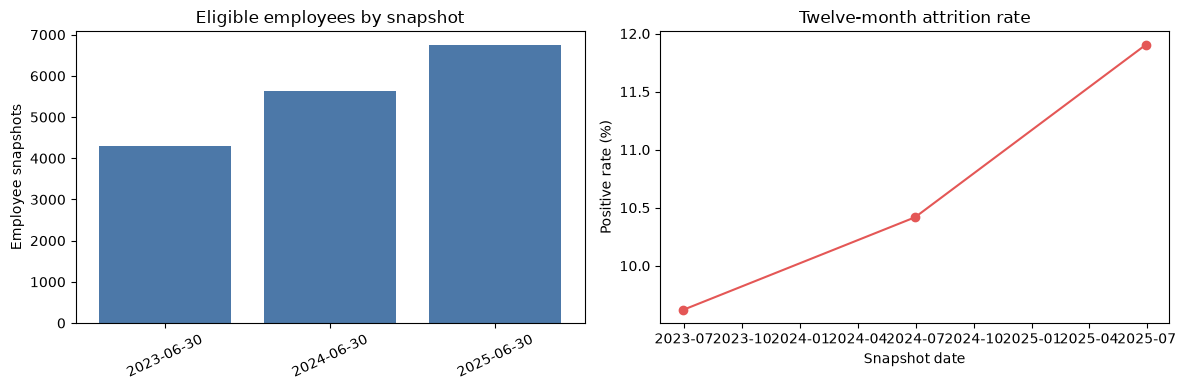

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    summary["snapshot_date"].dt.strftime("%Y-%m-%d"),
    summary["eligible_employees"],
    color="#4C78A8",
)
axes[0].set_title("Eligible employees by snapshot")
axes[0].set_ylabel("Employee snapshots")
axes[0].tick_params(axis="x", rotation=25)

axes[1].plot(
    summary["snapshot_date"],
    summary["positive_rate"] * 100,
    marker="o",
    color="#E45756",
)
axes[1].set_title("Twelve-month attrition rate")
axes[1].set_ylabel("Positive rate (%)")
axes[1].set_xlabel("Snapshot date")

figure.tight_layout()
plt.show()

## Repeated employees

The same active employee may appear at several dates. This is expected in a temporal panel, but later grouped validation must prevent employee overlap when an employee-disjoint test is required.

In [6]:
employee_snapshot_counts = historical.groupby("employee_id")["snapshot_date"].nunique()
employee_snapshot_counts.value_counts().sort_index().rename_axis(
    "number_of_snapshots"
).to_frame("employees")

,employees
number_of_snapshots,
1,2331
2,1900
3,3514


## Missing-value review

Missing performance values usually mean that no review existed by that historical snapshot. Missing training scores usually mean that no completed scored program existed during the trailing year.

In [7]:
(
    historical.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .head(15)
    .to_frame()
)

,missing_rate
days_since_last_change_event,0.746536
average_training_score_12m,0.453128
promotion_recommended,0.433395
days_since_review,0.433395
average_performance_rating,0.433395
goal_completion,0.433395
performance_rating,0.433395
prediction_end_date,0.000000
education_level,0.000000
organizational_level,0.000000


## Current scoring separation

Current employees have features but no known future attrition target.

In [8]:
pd.DataFrame(
    {
        "population": ["Historical", "Current scoring"],
        "rows": [len(historical), len(current)],
        "known_targets": [
            historical["attrition_next_12m"].notna().sum(),
            current["attrition_next_12m"].notna().sum(),
        ],
    }
)

,population,rows,known_targets
0,Historical,16673,16673
1,Current scoring,7409,0


## Conclusion

The temporal panel is ready for feature redundancy analysis in Checkpoint 39 and train/validation/test design in Checkpoint 40.